# Net-Hub EDA — 넷플릭스 콘텐츠, 뭘 더 확보해야 할까?

두 데이터를 붙여서 **공급보다 수요가 훨씬 큰 조합**을 찾는다.

| 데이터 | 역할 | 핵심 컬럼 |
|---|---|---|
| `netflix_titles.csv` (Kaggle) | **공급** — 어떤 콘텐츠가 깔려 있는가 | 제목, 국가, 장르, 유형 |
| `Engagement Report` (Netflix 공식) | **수요** — 뭘 얼마나 봤는가 | 제목, 시청시간 |

**목표 KPI**
- 매칭률 ≥ 25%
- EI(Efficiency Index) ≥ 1.5 조합 Top 5 도출

## 1. 데이터 로드

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)

kaggle = pd.read_csv('netflix_titles.csv')
engage = pd.read_excel('What_We_Watched_A_Netflix_Engagement_Report_2023Jan-Jun.xlsx',
                       sheet_name='Engagement', header=5)
engage = engage.drop(columns=[c for c in engage.columns if c.startswith('Unnamed')])

print('공급(Kaggle)  :', kaggle.shape)
print('수요(Engagement):', engage.shape)

공급(Kaggle)  : (8807, 12)
수요(Engagement): (18214, 4)


## 2. 제목 매칭

두 데이터를 합치려면 **제목으로 연결**해야 한다. 그런데 표기가 다르다.

| 문제 | 예시 |
|---|---|
| 다국어 병기 | `The Glory: Season 1 // 더 글로리: 시즌 1` |
| 시즌 표기 | `Wednesday: Season 1` vs `Wednesday` |
| 대소문자/특수문자 | `BEEF` vs `Beef` |

→ 양쪽 제목을 같은 규칙으로 정리해서 `title_key`를 만든다.

In [2]:
SEASON_PATTERN = re.compile(
    r':\s*(season|limited series|volume|vol\.?|part|chapter|book|collection)\b.*$',
    flags=re.IGNORECASE,
)
NUM_TAIL   = re.compile(r'\s+\d+\s*$')
NON_ALNUM  = re.compile(r'[^a-z0-9\s]')
MULTISPACE = re.compile(r'\s+')

def make_title_key(s):
    if not isinstance(s, str):
        return ''
    s = s.split('//')[0]              # 1) 다국어 병기 제거
    s = SEASON_PATTERN.sub('', s)     # 2) ': Season N' 등 제거
    s = s.lower()                     # 3) 소문자 통일
    s = NON_ALNUM.sub(' ', s)         # 4) 특수문자 → 공백
    s = MULTISPACE.sub(' ', s).strip()
    s = NUM_TAIL.sub('', s).strip()   # 5) 끝자리 숫자 제거 (시즌 번호)
    return s

kaggle['title_key'] = kaggle['title'].map(make_title_key)
engage['title_key'] = engage['Title'].map(make_title_key)

# 정규화 결과 확인
print('--- Engagement 정규화 예시 ---')
check = engage[engage['Title'].str.contains('Stranger Things', case=False, na=False)]
print(check[['Title', 'title_key']].to_string(index=False))

--- Engagement 정규화 예시 ---
                           Title                     title_key
               Stranger Things 4               stranger things
                 Stranger Things               stranger things
               Stranger Things 2               stranger things
               Stranger Things 3               stranger things
Beyond Stranger Things: Beyond 2 beyond stranger things beyond


### 시즌 문제 처리

두 데이터의 시즌 구분 방식이 다르다.

| | Kaggle | Engagement |
|---|---|---|
| Stranger Things | **1행**, `duration="3 Seasons"` | **시즌별 4행** |

Kaggle에 시즌 구분이 없으니 시즌별 매칭은 불가능하다. 그래서 **시리즈 전체로 묶어서 매칭**하되, 시즌이 많은 시리즈가 유리해지는 편향을 막기 위해 **시청시간을 시즌 수로 나눈다**.

예시:
- Stranger Things: 총 3.5억 시간 ÷ 4시즌 = **시즌당 8,700만**
- Wednesday: 총 5억 시간 ÷ 1시즌 = **시즌당 5억 그대로**

In [3]:
# Kaggle: duration에서 시즌 수 추출 (Movie는 1)
def extract_seasons(dur):
    if not isinstance(dur, str):
        return 1
    m = re.search(r'(\d+)\s*[Ss]eason', dur)
    return int(m.group(1)) if m else 1

kaggle['n_seasons_kaggle'] = kaggle['duration'].map(extract_seasons)

# Engagement: title_key 단위로 합산 + 시즌 수 카운트
engage_agg = (engage.groupby('title_key', as_index=False)
              .agg(hours_viewed=('Hours Viewed', 'sum'),
                   n_seasons_engage=('Title', 'nunique')))

# 매칭
master = kaggle.merge(engage_agg, on='title_key', how='inner')
master['n_seasons'] = master[['n_seasons_kaggle', 'n_seasons_engage']].max(axis=1)
master['hours_per_season'] = master['hours_viewed'] / master['n_seasons']

# 확인
st = master[master['title'].str.contains('Stranger Things', case=False, na=False) & (master['type']=='TV Show')]
print('Stranger Things:')
print(st[['title', 'n_seasons', 'hours_viewed', 'hours_per_season']].to_string(index=False))

Stranger Things:
          title  n_seasons  hours_viewed  hours_per_season
Stranger Things          4     347600000        86900000.0


In [4]:
# 매칭률
kaggle_keys = set(kaggle['title_key']) - {''}
engage_keys = set(engage_agg['title_key']) - {''}
matched     = kaggle_keys & engage_keys
match_rate  = len(matched) / len(kaggle_keys)

print(f'Kaggle  고유 타이틀 : {len(kaggle_keys):,}')
print(f'Engage  고유 타이틀 : {len(engage_keys):,}')
print(f'매칭된 타이틀       : {len(matched):,}')
print(f'\n매칭률   : {match_rate:.1%}  (목표 >= 25%) ✅')

Kaggle  고유 타이틀 : 8,701
Engage  고유 타이틀 : 14,712
매칭된 타이틀       : 4,872

매칭률   : 56.0%  (목표 >= 25%) ✅


## 3. 다중값 분해 + 가중치 분배

하나의 콘텐츠에 국가나 장르가 여러 개 달려 있을 수 있다.

예: `country = "United States, United Kingdom"`, `listed_in = "TV Dramas, TV Mysteries"`

이걸 그냥 복사하면 같은 콘텐츠가 중복 집계된다. 그래서 **1/n 가중치**로 분배한다.

→ 국가 2개 × 장르 2개 = 4개 행, 각 행에 가중치 `1/4`씩 부여

In [5]:
def split_multi(s):
    if not isinstance(s, str):
        return []
    return [x.strip() for x in s.split(',') if x.strip()]

tmp = master.copy()
tmp['countries'] = tmp['country'].map(split_multi)
tmp['genres']    = tmp['listed_in'].map(split_multi)
tmp = tmp[(tmp['countries'].map(len) > 0) & (tmp['genres'].map(len) > 0)].copy()
tmp['w'] = 1.0 / (tmp['countries'].map(len) * tmp['genres'].map(len))

exploded = tmp.explode('countries').explode('genres').reset_index(drop=True)
exploded['hours_w'] = exploded['hours_per_season'] * exploded['w']

print('분해 후 행수:', len(exploded))
exploded[['title', 'countries', 'genres', 'type', 'n_seasons', 'w', 'hours_w']].head(3)

분해 후 행수: 12512


,title,countries,genres,type,n_seasons,w,hours_w
0,Blood & Water,South Africa,International TV Shows,TV Show,3,0.333333,3.022222e+06
1,Blood & Water,South Africa,TV Dramas,TV Show,3,0.333333,3.022222e+06
2,Blood & Water,South Africa,TV Mysteries,TV Show,3,0.333333,3.022222e+06


## 4. Efficiency Index → Top 5

**EI = 시청 비중 / 공급 비중**

> 전체 카탈로그에서 이 조합이 차지하는 비율 대비, 실제로 얼마나 많이 시청됐는지의 비율.
> 예: EI = 5 → 카탈로그 비중은 1%인데 시청시간 비중은 5% → **있는 것보다 5배 더 찾아본다**는 뜻.

| EI 값 | 의미 |
|---|---|
| EI = 1 | 공급과 수요가 균형 |
| EI > 1 | **수요가 공급보다 큼** → 더 확보해야 함 |
| EI < 1 | 이미 충분히 많음 |

국가 × 장르 × 유형(Movie/TV Show) 조합별로 EI를 계산한다. 데이터가 너무 적은 조합은 제외(최소 10 이상).

In [6]:
MIN_SUPPLY = 10

seg = exploded.groupby(['countries', 'genres', 'type']).agg(
    supply=('w', 'sum'),
    hours=('hours_w', 'sum'),
    n_titles=('title', 'nunique'),
)
seg = seg[seg['supply'] >= MIN_SUPPLY].copy()
seg['supply_share'] = seg['supply'] / seg['supply'].sum()
seg['watch_share']  = seg['hours']  / seg['hours'].sum()
seg['EI']           = seg['watch_share'] / seg['supply_share']

top5 = seg.sort_values('EI', ascending=False).head(5)
print('더 확보해야 할 콘텐츠 Top 5:')
top5[['n_titles', 'supply_share', 'watch_share', 'EI']]

더 확보해야 할 콘텐츠 Top 5:


n_titles  supply_share  watch_share         EI
countries     genres                type                                                   
United States Romantic TV Shows     TV Show        29      0.003734     0.048216  12.911868
              TV Dramas             TV Show       167      0.023638     0.116159   4.914053
              TV Mysteries          TV Show        36      0.003679     0.014885   4.046534
              TV Action & Adventure TV Show        79      0.008374     0.033643   4.017417
              TV Sci-Fi & Fantasy   TV Show        48      0.005490     0.021362   3.891153

In [7]:
n_over = (seg['EI'] >= 1.5).sum()
print(f'EI >= 1.5 조합 수: {n_over} / 전체 {len(seg)}')

EI >= 1.5 조합 수: 19 / 전체 82


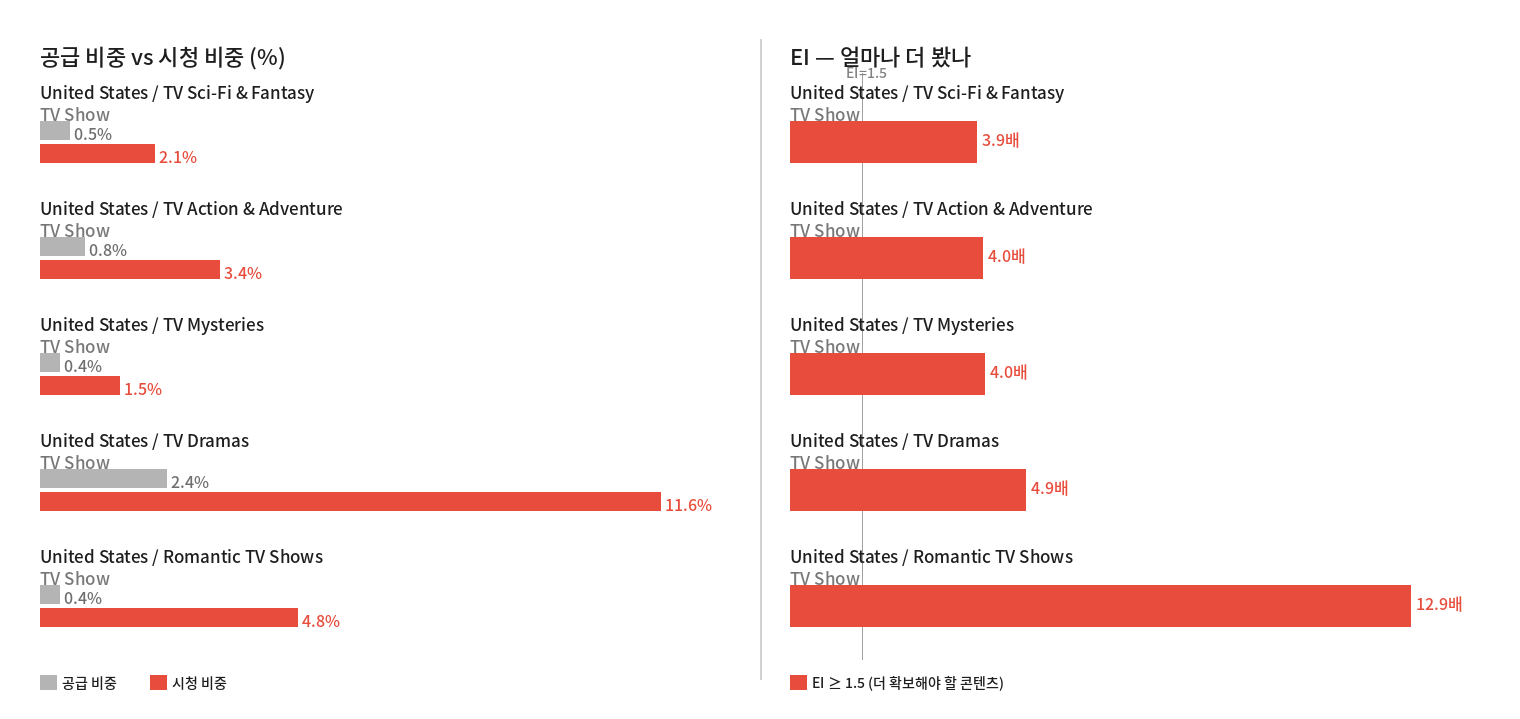

In [8]:
import numpy as np
from PIL import Image, ImageDraw, ImageFont

KO      = '/usr/share/fonts/opentype/noto/NotoSansCJK-Medium.ttc'
F_TITLE = ImageFont.truetype(KO, 22)
F_LABEL = ImageFont.truetype(KO, 17)
F_VAL   = ImageFont.truetype(KO, 16)
F_SMALL = ImageFont.truetype(KO, 14)

top5_d = top5.reset_index().sort_values('EI').reset_index(drop=True)
# 레이블 2줄: 국가/장르(1줄) + 유형(2줄)
top5_d['lbl1'] = top5_d['countries'] + ' / ' + top5_d['genres']
top5_d['lbl2'] = top5_d['type']

N        = len(top5_d)
W, H     = 1500, 700       # 높이 확대
PAD      = 30
HALF     = W // 2
ROW_H    = (H - 120) // N  # 행당 높이
LBL_H    = 42              # 레이블 2줄 높이
BAR_H    = 18
GAP      = 5
BG, FG   = (255,255,255), (30,30,30)
C_SUP    = (180,180,180)
C_WAT    = (231,76,60)
C_EI     = (231,76,60)

img  = Image.new('RGB', (W, H), BG)
draw = ImageDraw.Draw(img)
TOP_Y = 70

def draw_label(draw, x, y, l1, l2, font, fill):
    draw.text((x, y),    l1, font=font, fill=fill)
    draw.text((x, y+22), l2, font=font, fill=(120,120,120))

# ── 왼쪽: 공급 vs 시청 비중 ──
draw.text((PAD, PAD), '공급 비중 vs 시청 비중 (%)', font=F_TITLE, fill=FG)
BAR_W   = HALF - PAD*2 - 70
scale_l = BAR_W / (max(top5_d['supply_share'].max(), top5_d['watch_share'].max()) * 100)

for i, row in top5_d.iterrows():
    yb = TOP_Y + i * ROW_H
    draw_label(draw, PAD, yb, row['lbl1'], row['lbl2'], F_LABEL, FG)
    by = yb + LBL_H
    sw = int(row['supply_share'] * 100 * scale_l)
    draw.rectangle([PAD, by, PAD+sw, by+BAR_H], fill=C_SUP)
    draw.text((PAD+sw+5, by), f"{row['supply_share']*100:.1f}%", font=F_VAL, fill=(110,110,110))
    ww = int(row['watch_share'] * 100 * scale_l)
    draw.rectangle([PAD, by+BAR_H+GAP, PAD+ww, by+BAR_H*2+GAP], fill=C_WAT)
    draw.text((PAD+ww+5, by+BAR_H+GAP), f"{row['watch_share']*100:.1f}%", font=F_VAL, fill=C_WAT)

leg_y = H - 38
draw.rectangle([PAD, leg_y+4, PAD+16, leg_y+18], fill=C_SUP)
draw.text((PAD+22, leg_y), '공급 비중', font=F_SMALL, fill=FG)
draw.rectangle([PAD+110, leg_y+4, PAD+126, leg_y+18], fill=C_WAT)
draw.text((PAD+132, leg_y), '시청 비중', font=F_SMALL, fill=FG)

draw.line([(HALF, PAD), (HALF, H-PAD)], fill=(210,210,210), width=2)

# ── 오른쪽: EI ──
X1       = HALF + PAD
EI_BAR_W = HALF - PAD*2 - 70
draw.text((X1, PAD), 'EI — 얼마나 더 봤나', font=F_TITLE, fill=FG)
scale_r = EI_BAR_W / top5_d['EI'].max()
ref_x   = X1 + int(1.5 * scale_r)
draw.line([(ref_x, 64), (ref_x, H-50)], fill=(160,160,160), width=1)
draw.text((ref_x-16, 52), 'EI=1.5', font=F_SMALL, fill=(130,130,130))

for i, row in top5_d.iterrows():
    yb  = TOP_Y + i * ROW_H
    draw_label(draw, X1, yb, row['lbl1'], row['lbl2'], F_LABEL, FG)
    by  = yb + LBL_H
    ew  = int(row['EI'] * scale_r)
    col = C_EI if row['EI'] >= 1.5 else (200,200,200)
    draw.rectangle([X1, by, X1+ew, by+BAR_H*2+GAP], fill=col)
    draw.text((X1+ew+6, by+6), f"{row['EI']:.1f}배", font=F_VAL, fill=col)

draw.rectangle([X1, leg_y+4, X1+16, leg_y+18], fill=C_EI)
draw.text((X1+22, leg_y), 'EI ≥ 1.5 (더 확보해야 할 콘텐츠)', font=F_SMALL, fill=FG)

plt.figure(figsize=(15, 7))
plt.imshow(img)
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

In [9]:
# 최종 수치 정리
print('='*70)
print('  더 확보해야 할 콘텐츠 Top 5  (국가 x 장르 x 유형)')
print('='*70)
for rank, (_, row) in enumerate(top5.reset_index().iterrows(), 1):
    print(f"  {rank}위  {row['countries']:15s} | {row['genres']:25s} | {row['type']:8s} | EI = {row['EI']:.1f}x")
print('='*70)

  더 확보해야 할 콘텐츠 Top 5  (국가 x 장르 x 유형)
  1위  United States   | Romantic TV Shows         | TV Show  | EI = 12.9x
  2위  United States   | TV Dramas                 | TV Show  | EI = 4.9x
  3위  United States   | TV Mysteries              | TV Show  | EI = 4.0x
  4위  United States   | TV Action & Adventure     | TV Show  | EI = 4.0x
  5위  United States   | TV Sci-Fi & Fantasy       | TV Show  | EI = 3.9x


---
## 결론

### 핵심 질문: "어떤 콘텐츠를 더 확보해야 하는가?"

**→ 미국 제작 TV Show.** 특히 로맨틱 · 드라마 · 액션 장르.

Top 5가 전부 **미국 × TV Show** 조합이다. 카탈로그에는 적게 깔려 있는데 시청자는 압도적으로 많이 보고 있어서, **지금 공급이 가장 부족한 영역**이 여기다.

---

### 비즈니스 액션

| 액션 | 구체적으로 |
|---|---|
| **라이선스 계약** | 미국 제작사 TV Show 협상 시, 로맨틱 / 드라마 / 액션 장르를 1순위 타겟으로 |
| **자체 제작 투자** | 외부 확보가 어려우면, 이 장르의 오리지널 시리즈 제작 투자 근거로 활용 |
| **예산 재배치** | EI < 1(이미 충분히 많은) 콘텐츠의 갱신 비용을 줄이고, 위 조합으로 예산 이동 |

---

### 주의

- "미국에서 잘 팔린다"가 아니라, **"미국이 만든 콘텐츠가 글로벌에서 많이 소비됐다"** 는 뜻이다.
- 매칭된 표본은 2021년 이전에 등록된 콘텐츠 중 2023년까지 살아남은 것들이라, 신작에 그대로 적용하면 과도한 일반화가 된다.